# Cyber Security Threat Detection with ML and Deep Learning (CICIDS2017)

One notebook covering the full workflow:

| Part | Content |
|---|---|
| 1 | Environment setup validation |
| 2 | Load data and preprocess (missing values, encoding, normalization) |
| 3 | ML threat classification: Logistic Regression and Decision Tree, with detailed evaluation plots |
| 4 | Neural network (MLP) vs classical ML: accuracy, training time, feasibility |

EDA is assumed done separately. The target is binary: **normal** (`BENIGN`) vs **suspicious** (any attack).

## Part 1: Environment setup validation

```bash
python3 -m venv venv
source venv/bin/activate   # Windows: venv\Scripts\activate
pip install -r requirements.txt
jupyter notebook
```

In [1]:
import numpy as np, pandas as pd, sklearn, matplotlib, seaborn
from sklearn.linear_model import LogisticRegression

print("numpy", np.__version__, "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__,
      "| matplotlib", matplotlib.__version__, "| seaborn", seaborn.__version__)

# Tiny end-to-end sanity check
_X = np.random.rand(200, 3); _y = (_X.sum(axis=1) > 1.5).astype(int)
print("Sample model accuracy:", round(LogisticRegression().fit(_X, _y).score(_X, _y), 3))
print("Setup OK")

numpy 2.2.6 | pandas 2.2.2 | scikit-learn 1.5.2 | matplotlib 3.9.2 | seaborn 0.13.2
Sample model accuracy: 0.985
Setup OK


## Part 2: Load data and preprocess

In [2]:
import glob, os, time, warnings
warnings.filterwarnings("ignore")

# Folder with the CICIDS2017 CSV files (all CSVs in it are concatenated). Change if needed.
DATA_DIR = "../data"
MAX_ROWS = 200_000        # sample size for speed; set to None to use the full dataset

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
real = [f for f in files if "sample_cicids_like" not in f]
files = real or files     # real data takes priority over the synthetic placeholder
print("Loading:", [os.path.basename(f) for f in files])

df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)
df.columns = df.columns.str.strip()                       # CICIDS headers contain stray spaces
df = df.replace([np.inf, -np.inf], np.nan)                # Flow Bytes/s etc. contain inf
if MAX_ROWS and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)

df["is_attack"] = (df["Label"].astype(str).str.strip().str.upper() != "BENIGN").astype(int)
print(df.shape)
df["is_attack"].map({0: "Normal", 1: "Suspicious"}).value_counts()

Loading: ['cicids2017_cleaned.csv']
(200000, 72)


is_attack
Normal        166267
Suspicious     33733
Name: count, dtype: int64

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

y = df["is_attack"]
X = df.drop(columns=["Label", "is_attack"]).copy()

# Categorical feature: bucket Destination Port (one-hot of ~65k raw ports is wasteful)
X["Port Class"] = pd.cut(X["Destination Port"], [-1, 1023, 49151, 65535],
                         labels=["well_known", "registered", "dynamic"]).astype(str)
cat_cols = ["Port Class"]
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),   # missing values
                      ("scale", StandardScaler())]), num_cols),       # normalization
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),        # encoding
], sparse_threshold=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

# Fit the preprocessing on the training split only (no leakage), then transform both splits.
Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)
feat_names = preprocess.get_feature_names_out()
print("Train:", Xtr.shape, "| Test:", Xte.shape, "| Features after encoding:", len(feat_names))

Train: (150000, 73) | Test: (50000, 73) | Features after encoding: 73


In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, classification_report, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)

# Plot style: recessive grid, no top/right spines, ink-colored text, one color per entity.
INK, INK2, SURFACE, GRID = "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"
CLR = {"Normal": "#2a78d6", "Suspicious": "#eb6834"}
MODEL_CLR = {"Logistic Regression": "#2a78d6", "Decision Tree": "#eb6834", "Neural Net (MLP 64-32)": "#1baf7a"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titlesize": 11, "axes.axisbelow": True,
    "axes.titleweight": "semibold", "legend.frameon": False, "figure.dpi": 110, "lines.linewidth": 2,
})
for _k in ("axes.titlelocation", "axes.titleloc"):     # key name differs across matplotlib versions
    try:
        plt.rcParams[_k] = "left"; break
    except KeyError:
        pass

fitted, preds, probas, rows = {}, {}, {}, []

def evaluate(name, clf):
    """Fit on the transformed training data, time it, and store predictions and metrics."""
    t0 = time.perf_counter(); clf.fit(Xtr, y_train); train_t = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = clf.predict(Xte);  pred_t = time.perf_counter() - t0
    proba = clf.predict_proba(Xte)[:, 1]
    fitted[name], preds[name], probas[name] = clf, pred, proba
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred), "F1-score": f1_score(y_test, pred),
                 "ROC AUC": roc_auc_score(y_test, proba), "PR AUC": average_precision_score(y_test, proba),
                 "Train time (s)": train_t, "Predict ms / 1k flows": pred_t / len(Xte) * 1e6})
    print(f"{name}: trained in {train_t:.2f}s")

def results_table():
    return pd.DataFrame(rows).set_index("Model").round(4)

def confusion_grid(names):
    fig, axes = plt.subplots(2, len(names), figsize=(4.6 * len(names), 8), squeeze=False)
    for j, n in enumerate(names):
        for i, (norm, fmt, ttl) in enumerate([(None, "d", "counts"), ("true", ".2%", "share of true class")]):
            ConfusionMatrixDisplay.from_predictions(y_test, preds[n], display_labels=["Normal", "Suspicious"],
                ax=axes[i, j], colorbar=False, cmap="Blues", normalize=norm, values_format=fmt)
            axes[i, j].set_title(f"{n} ({ttl})"); axes[i, j].grid(False)
    plt.tight_layout(); plt.show()

def curves(names):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
    for n in names:
        fpr, tpr, _ = roc_curve(y_test, probas[n])
        ax[0].plot(fpr, tpr, color=MODEL_CLR[n], label=f"{n} (AUC {roc_auc_score(y_test, probas[n]):.4f})")
        p, r, _ = precision_recall_curve(y_test, probas[n])
        ax[1].plot(r, p, color=MODEL_CLR[n], label=f"{n} (AP {average_precision_score(y_test, probas[n]):.4f})")
    ax[0].plot([0, 1], [0, 1], "--", color=INK2, lw=1)
    ax[0].set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
    ax[1].set(title="Precision-recall curve", xlabel="Recall", ylabel="Precision")
    ax[0].legend(loc="lower right"); ax[1].legend(loc="lower left")
    plt.tight_layout(); plt.show()

## Part 3: ML-based threat classification
Logistic Regression (linear baseline) and a Decision Tree (non-linear, interpretable).

In [30]:
evaluate("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced"))
from sklearn.tree import DecisionTreeClassifier, plot_tree
evaluate("Decision Tree", DecisionTreeClassifier(max_depth=12, class_weight="balanced", random_state=42))
ML = ["Logistic Regression", "Decision Tree"]

Logistic Regression: trained in 17.63s
Decision Tree: trained in 23.43s


### 3.1 Metrics

In [31]:
for n in ML:
    print(f"=== {n} ===")
    print(classification_report(y_test, preds[n], target_names=["Normal", "Suspicious"], digits=4))
results_table().loc[ML, ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC", "PR AUC"]]

=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal     0.9931    0.9283    0.9596     41567
  Suspicious     0.7326    0.9683    0.8342      8433

    accuracy                         0.9351     50000
   macro avg     0.8629    0.9483    0.8969     50000
weighted avg     0.9492    0.9351    0.9385     50000

=== Decision Tree ===
              precision    recall  f1-score   support

      Normal     0.9982    0.9973    0.9977     41567
  Suspicious     0.9865    0.9912    0.9889      8433

    accuracy                         0.9962     50000
   macro avg     0.9924    0.9942    0.9933     50000
weighted avg     0.9962    0.9962    0.9962     50000



,Accuracy,Precision,Recall,F1-score,ROC AUC,PR AUC
Model,,,,,,
Logistic Regression,0.9351,0.7326,0.9683,0.8342,0.9857,0.9388
Decision Tree,0.9962,0.9865,0.9912,0.9889,0.9983,0.9944


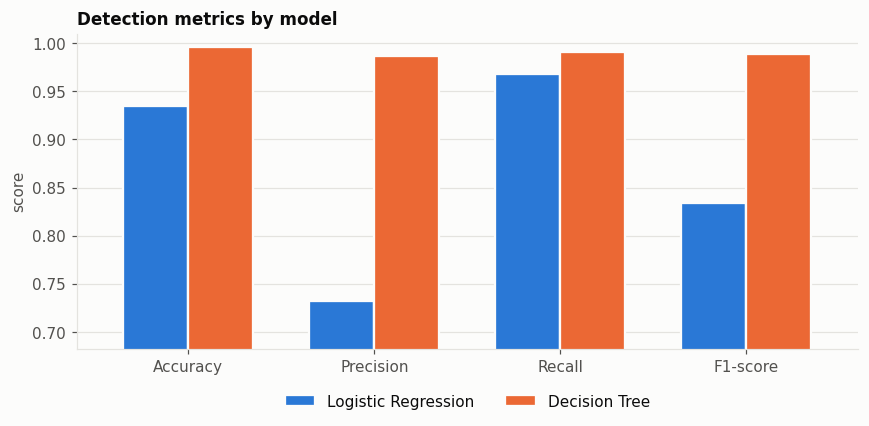

In [32]:
# Metric comparison
t = results_table().loc[ML, ["Accuracy", "Precision", "Recall", "F1-score"]].T
ax = t.plot.bar(figsize=(8, 4), rot=0, width=0.7, color=[MODEL_CLR[n] for n in ML], edgecolor=SURFACE, linewidth=1.5)
ax.set_ylim(max(0, t.values.min() - 0.05), 1.01); ax.set_title("Detection metrics by model"); ax.set_ylabel("score")
ax.grid(axis="x", visible=False); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=len(ML))
plt.tight_layout(); plt.show()

### 3.2 Confusion matrices
Top row: raw counts. Bottom row: normalized per true class, so the diagonal reads as detection rate (Suspicious) and true-negative rate (Normal).

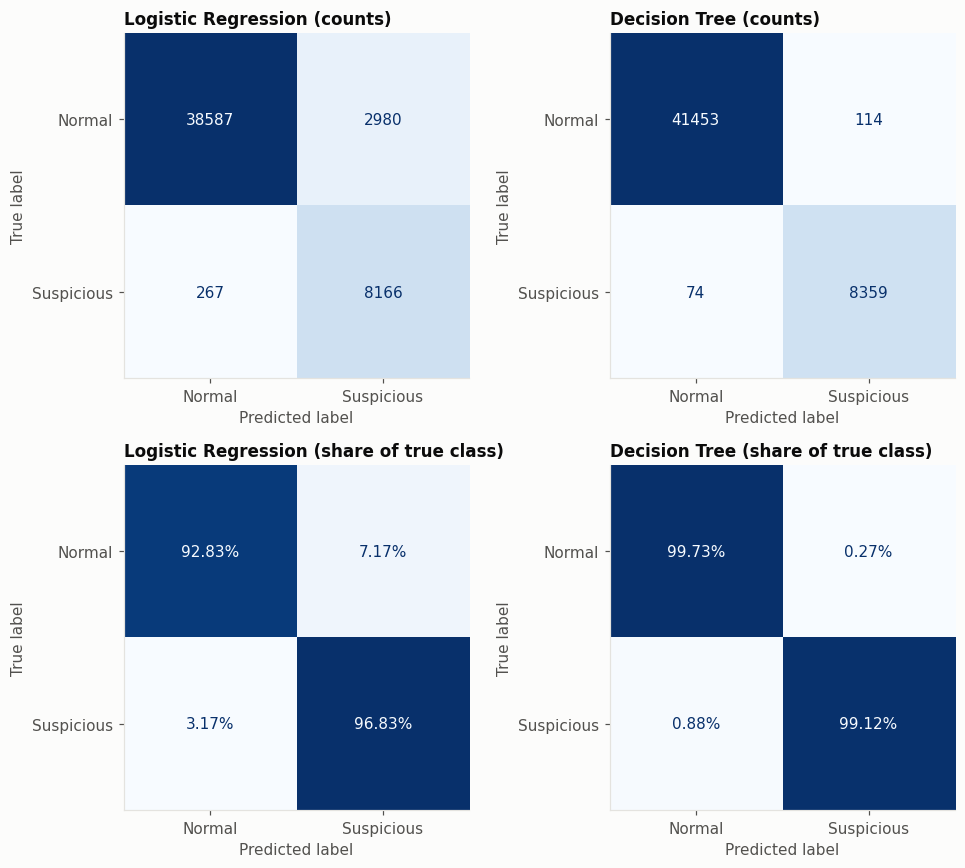

In [33]:
confusion_grid(ML)

### 3.3 ROC and precision-recall curves
PR curves are the more informative view when attacks are the minority class.

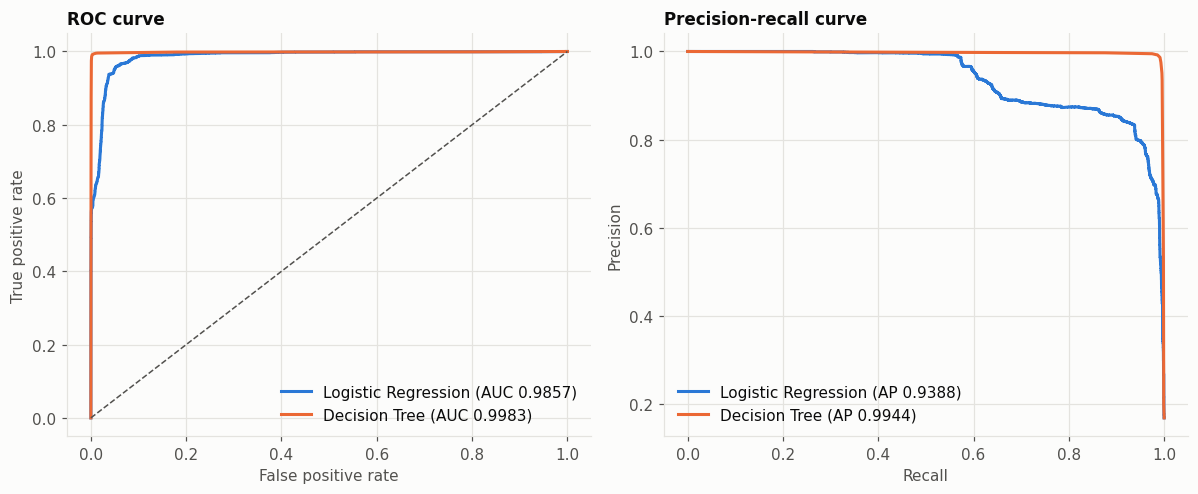

In [34]:
curves(ML)

### 3.4 Score distributions
How well each model separates the two classes. Overlap between the colors is where errors come from (log y-axis).

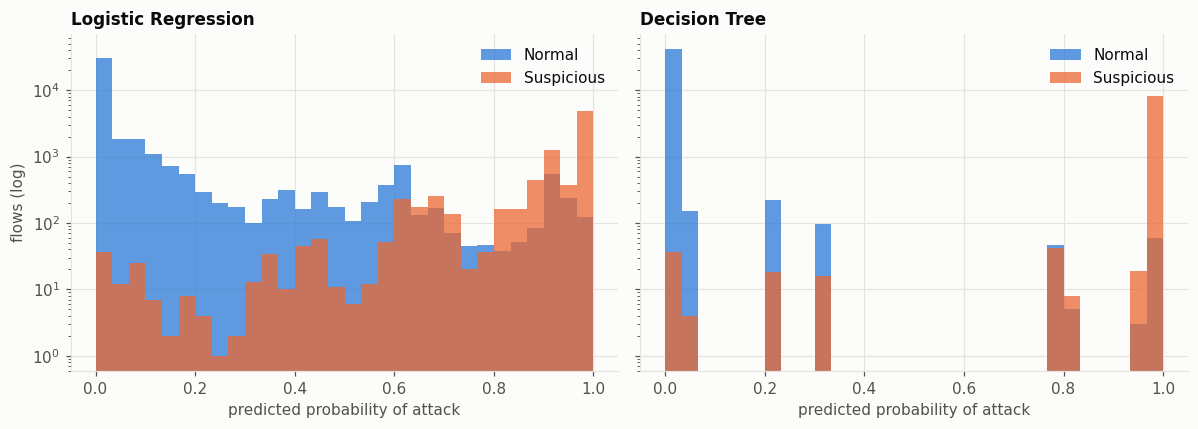

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, n in zip(axes, ML):
    for cls, lab in [(0, "Normal"), (1, "Suspicious")]:
        ax.hist(probas[n][(y_test == cls).values], bins=30, range=(0, 1), alpha=0.75, color=CLR[lab], label=lab)
    ax.set_yscale("log"); ax.set_title(n); ax.set_xlabel("predicted probability of attack"); ax.legend()
axes[0].set_ylabel("flows (log)"); plt.tight_layout(); plt.show()

### 3.5 Detection rate per attack type
Share of each attack type correctly flagged as suspicious. Small classes (low *n*) are noisy; read them with care.

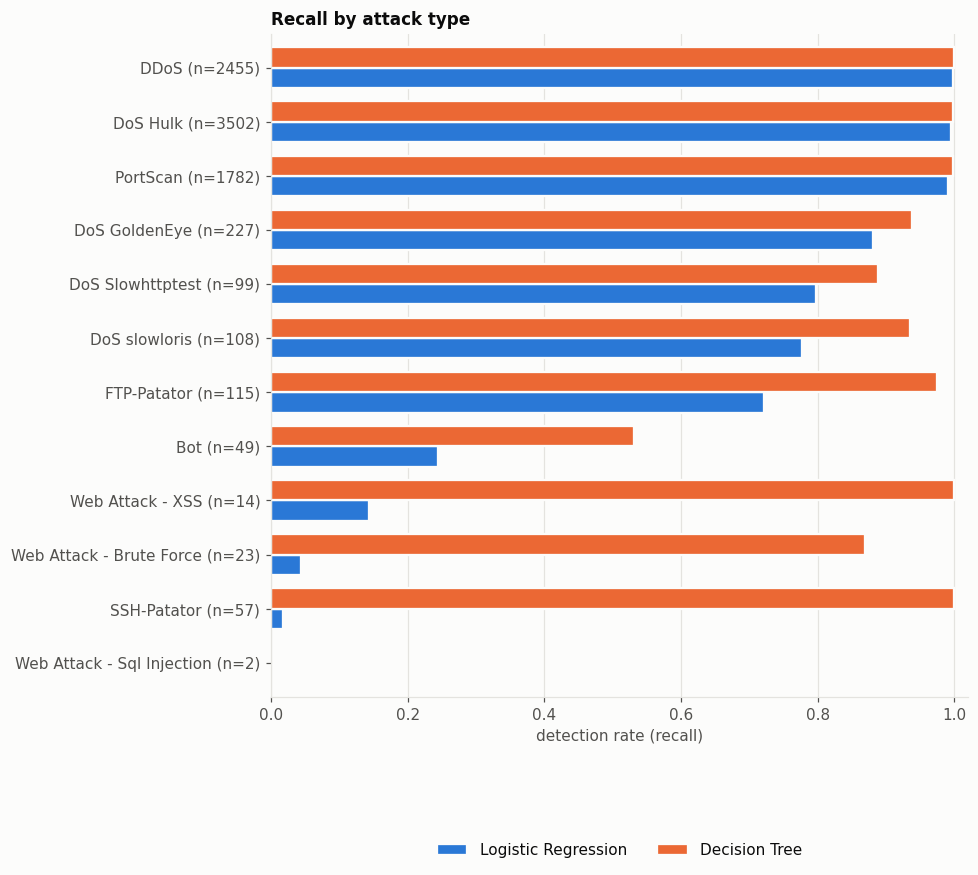

,Logistic Regression,Decision Tree
Web Attack - Sql Injection (n=2),0.000,0.000
SSH-Patator (n=57),0.018,1.000
Web Attack - Brute Force (n=23),0.043,0.870
Web Attack - XSS (n=14),0.143,1.000
Bot (n=49),0.245,0.531
FTP-Patator (n=115),0.722,0.974
DoS slowloris (n=108),0.778,0.935
DoS Slowhttptest (n=99),0.798,0.889
DoS GoldenEye (n=227),0.881,0.938
PortScan (n=1782),0.990,0.998


In [36]:
def per_attack_recall(names):
    lab = df.loc[X_test.index, "Label"].astype(str).str.strip()
    atk = lab[lab.str.upper() != "BENIGN"]
    rec = pd.DataFrame({n: pd.Series(preds[n], index=X_test.index)[atk.index].groupby(atk).mean() for n in names})
    counts = atk.value_counts()
    rec.index = [f"{l} (n={counts[l]})" for l in rec.index]
    rec = rec.sort_values(names[0])
    ax = rec.plot.barh(color=[MODEL_CLR[n] for n in names], width=0.75, edgecolor=SURFACE, linewidth=1.5,
                       figsize=(9, max(3, 0.55 * len(rec) + 1.5)))
    ax.set_xlim(0, 1.02); ax.set_xlabel("detection rate (recall)"); ax.set_title("Recall by attack type")
    ax.grid(axis="y", visible=False)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=len(names)); plt.tight_layout(); plt.show()
    return rec.round(3)

per_attack_recall(ML)

### 3.6 What drives the predictions

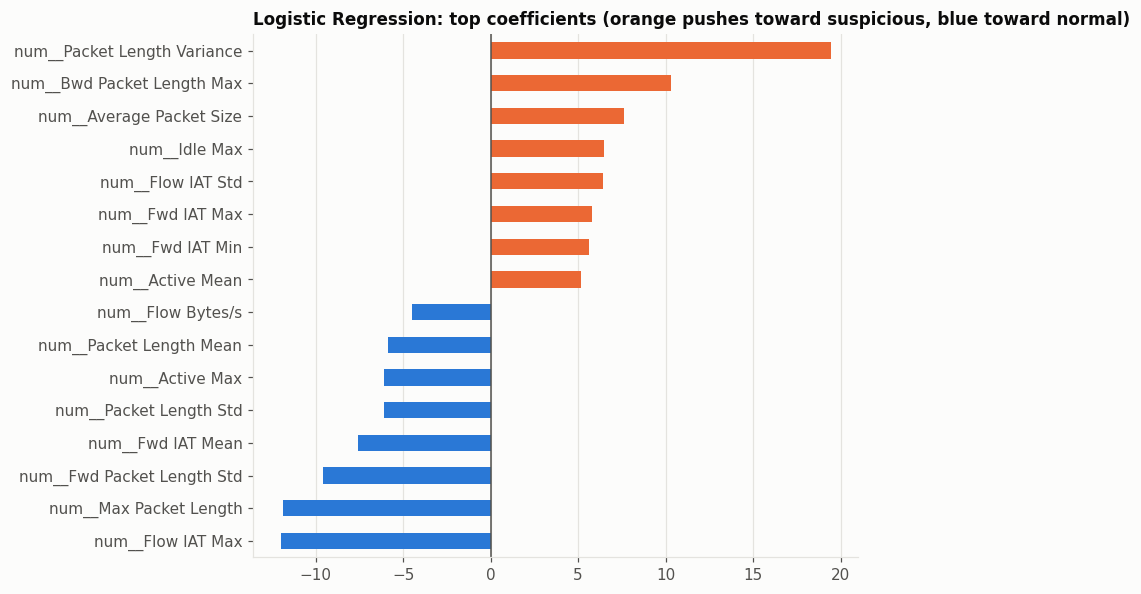

In [37]:
# Logistic Regression: coefficients (on standardized features, so magnitudes are comparable)
coef = pd.Series(fitted["Logistic Regression"].coef_[0], index=feat_names)
top = pd.concat([coef.nsmallest(8), coef.nlargest(8)]).sort_values()
ax = top.plot.barh(figsize=(8, 5.5), color=[CLR["Suspicious"] if v > 0 else CLR["Normal"] for v in top])
ax.set_title("Logistic Regression: top coefficients (orange pushes toward suspicious, blue toward normal)")
ax.axvline(0, color=INK2, lw=1); ax.grid(axis="y", visible=False); plt.tight_layout(); plt.show()

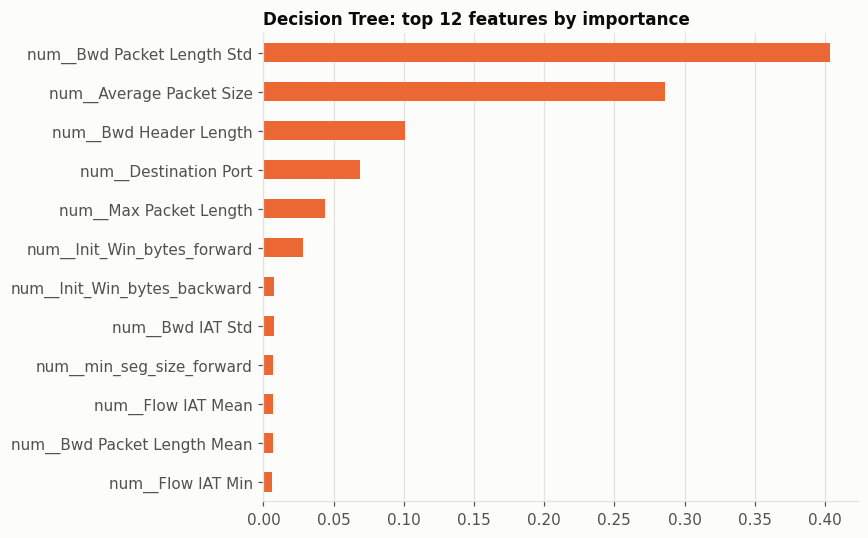

In [38]:
# Decision Tree: feature importance
imp = pd.Series(fitted["Decision Tree"].feature_importances_, index=feat_names).sort_values().tail(12)
ax = imp.plot.barh(figsize=(8, 5), color=MODEL_CLR["Decision Tree"])
ax.set_title("Decision Tree: top 12 features by importance"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

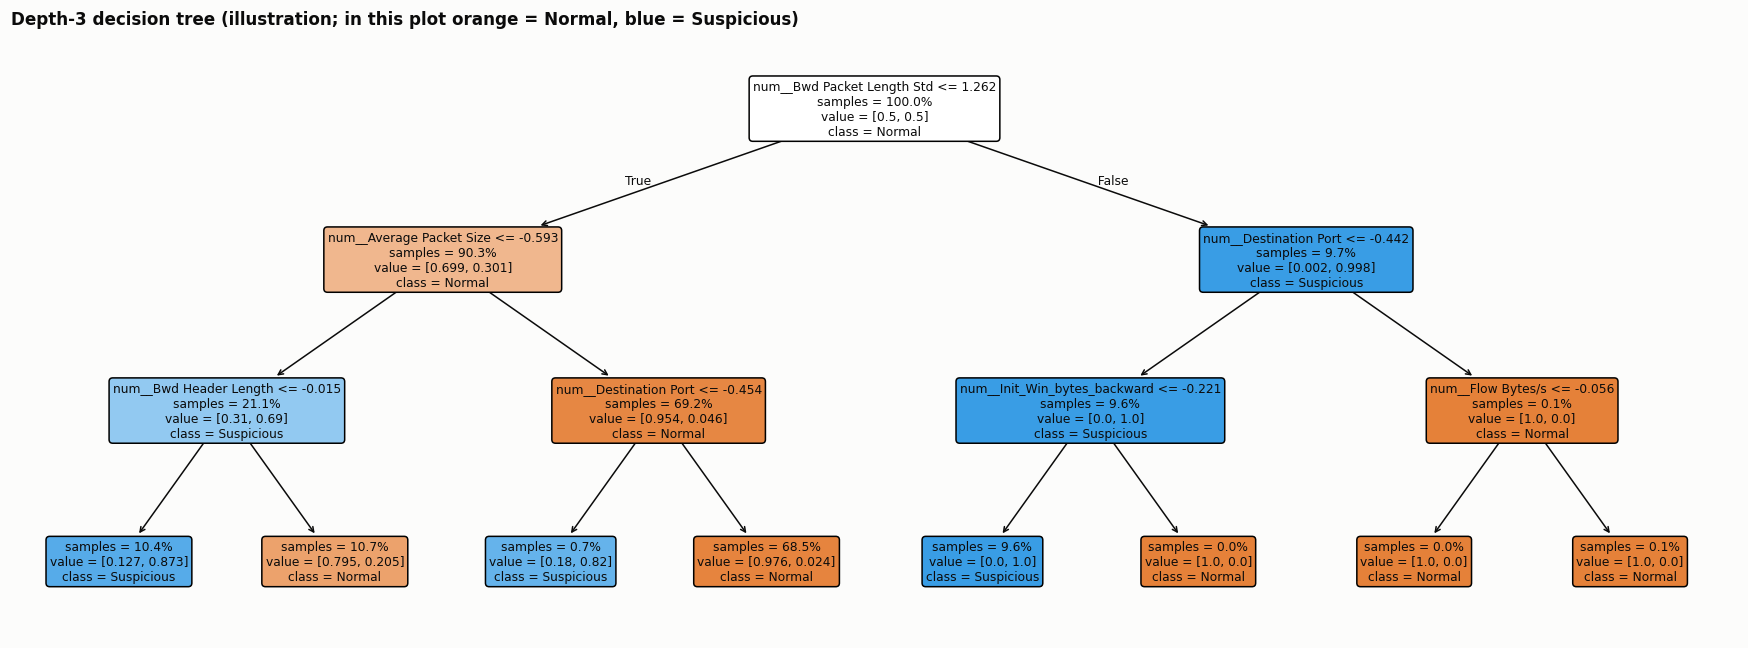

In [39]:
# A readable shallow tree (depth 3) to show the kind of rules the model learns
shallow = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42).fit(Xtr, y_train)
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(shallow, feature_names=list(feat_names), class_names=["Normal", "Suspicious"], filled=True,
          rounded=True, impurity=False, proportion=True, fontsize=8, ax=ax)
ax.set_title("Depth-3 decision tree (illustration; in this plot orange = Normal, blue = Suspicious)"); plt.tight_layout(); plt.show()

## Part 4: Introduction to deep learning (MLP) vs classical ML
A simple feed-forward neural network (two hidden layers, 64 and 32 units) trained on the same preprocessed split.

In [40]:
from sklearn.neural_network import MLPClassifier
evaluate("Neural Net (MLP 64-32)", MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True,
                                                 max_iter=200, random_state=42,verbose =1))
ALL = list(fitted)
results_table()



Iteration 1, loss = 0.10172371
Validation score: 0.971000
Iteration 2, loss = 0.06257315
Validation score: 0.973000
Iteration 3, loss = 0.05466258
Validation score: 0.977800
Iteration 4, loss = 0.04903421
Validation score: 0.980067
Iteration 5, loss = 0.04551663
Validation score: 0.981133
Iteration 6, loss = 0.04247819
Validation score: 0.981600
Iteration 7, loss = 0.04005075
Validation score: 0.983867
Iteration 8, loss = 0.03839907
Validation score: 0.985600
Iteration 9, loss = 0.03587172
Validation score: 0.986867
Iteration 10, loss = 0.03334981
Validation score: 0.988200
Iteration 11, loss = 0.03202942
Validation score: 0.987200
Iteration 12, loss = 0.03041061
Validation score: 0.990400
Iteration 13, loss = 0.02959266
Validation score: 0.990133
Iteration 14, loss = 0.02679292
Validation score: 0.993467
Iteration 15, loss = 0.02466827
Validation score: 0.991933
Iteration 16, loss = 0.02413276
Validation score: 0.992400
Iteration 17, loss = 0.02314901
Validation score: 0.992867
Iterat

,Accuracy,Precision,Recall,F1-score,ROC AUC,PR AUC,Train time (s),Predict ms / 1k flows
Model,,,,,,,,
Logistic Regression,0.9351,0.7326,0.9683,0.8342,0.9857,0.9388,17.6299,0.4846
Decision Tree,0.9962,0.9865,0.9912,0.9889,0.9983,0.9944,23.4305,0.6526
Neural Net (MLP 64-32),0.9944,0.9821,0.9845,0.9833,0.9995,0.9979,75.7270,2.3841


### 4.1 Detection performance

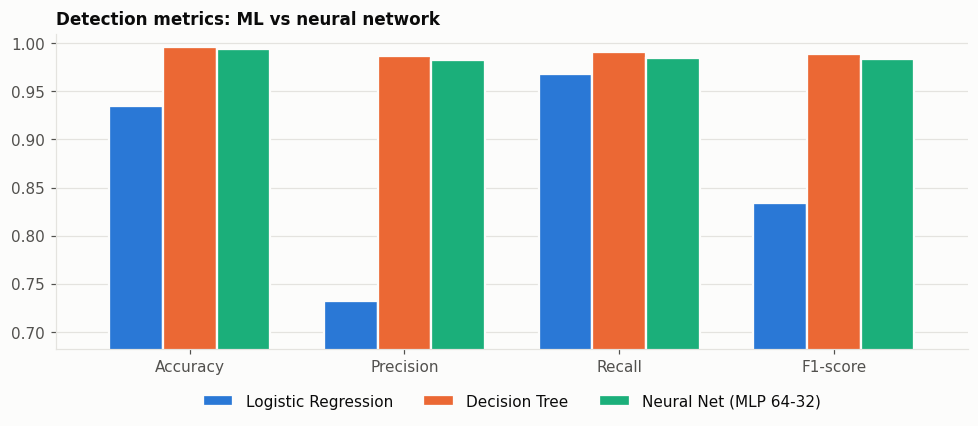

In [41]:
t = results_table()[["Accuracy", "Precision", "Recall", "F1-score"]].T
ax = t.plot.bar(figsize=(9, 4), rot=0, width=0.75, color=[MODEL_CLR[n] for n in ALL], edgecolor=SURFACE, linewidth=1.5)
ax.set_ylim(max(0, t.values.min() - 0.05), 1.01); ax.set_title("Detection metrics: ML vs neural network")
ax.grid(axis="x", visible=False); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=len(ALL))
plt.tight_layout(); plt.show()

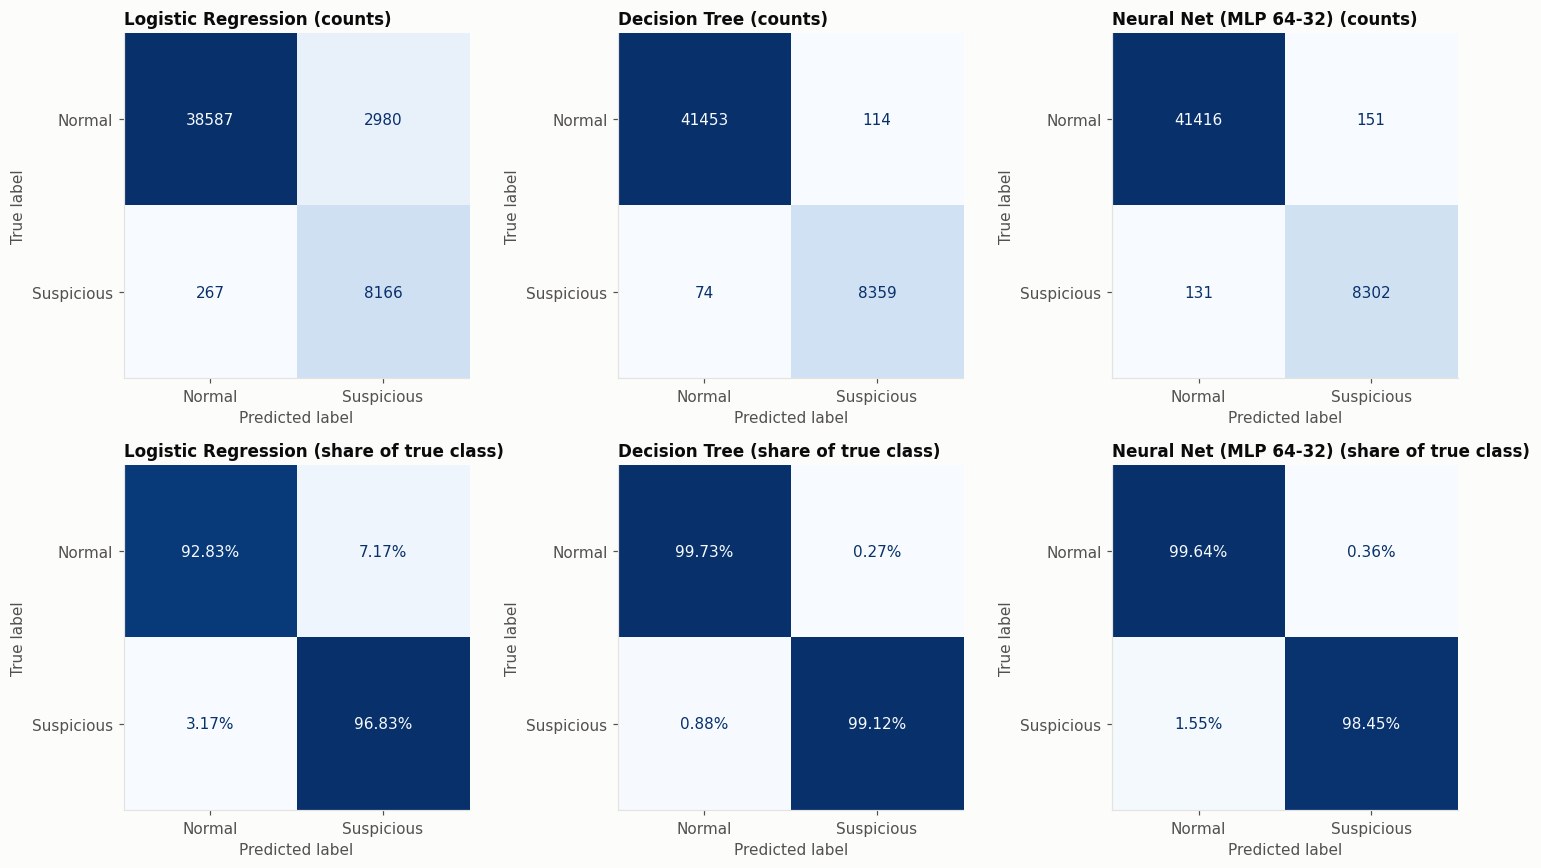

In [42]:
confusion_grid(ALL)

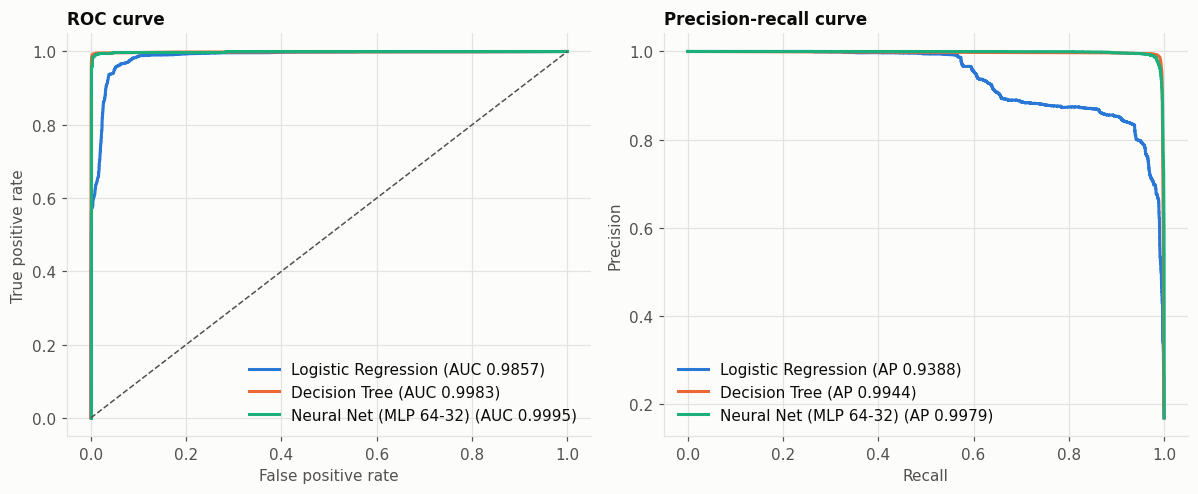

In [43]:
curves(ALL)

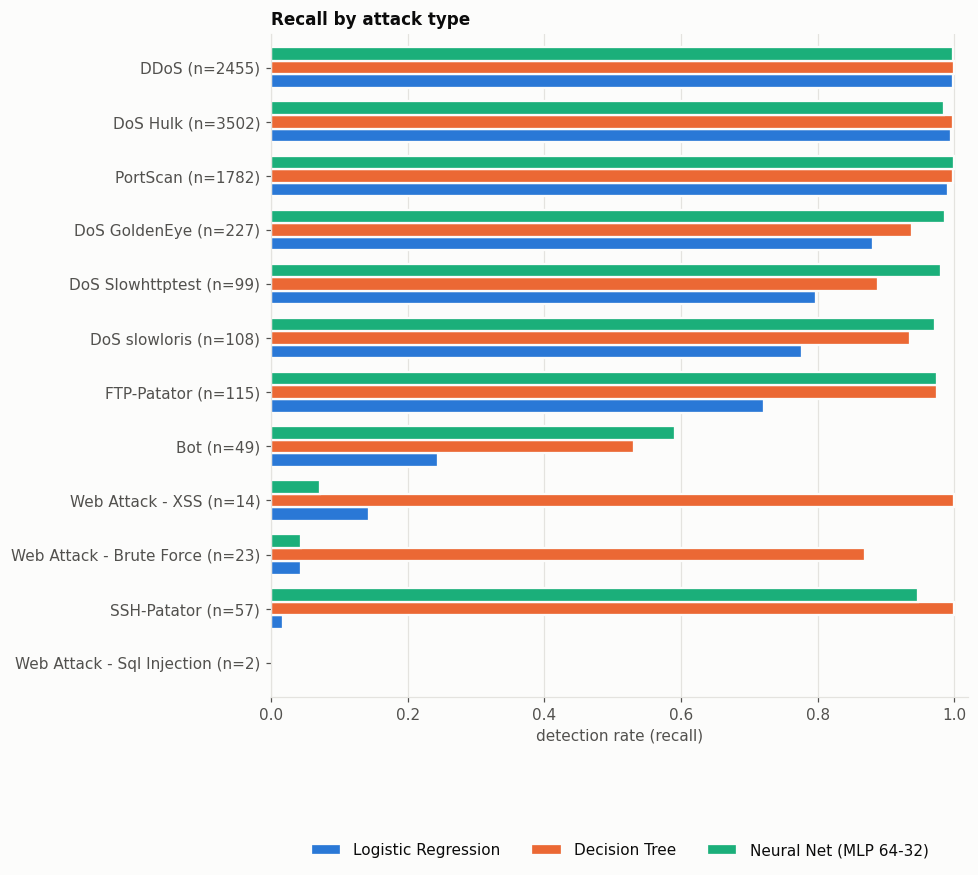

,Logistic Regression,Decision Tree,Neural Net (MLP 64-32)
Web Attack - Sql Injection (n=2),0.000,0.000,0.000
SSH-Patator (n=57),0.018,1.000,0.947
Web Attack - Brute Force (n=23),0.043,0.870,0.043
Web Attack - XSS (n=14),0.143,1.000,0.071
Bot (n=49),0.245,0.531,0.592
FTP-Patator (n=115),0.722,0.974,0.974
DoS slowloris (n=108),0.778,0.935,0.972
DoS Slowhttptest (n=99),0.798,0.889,0.980
DoS GoldenEye (n=227),0.881,0.938,0.987
PortScan (n=1782),0.990,0.998,0.999


In [44]:
per_attack_recall(ALL)

### 4.2 Training time and feasibility

In [45]:
rows[:] = list({r["Model"]: r for r in rows}.values())

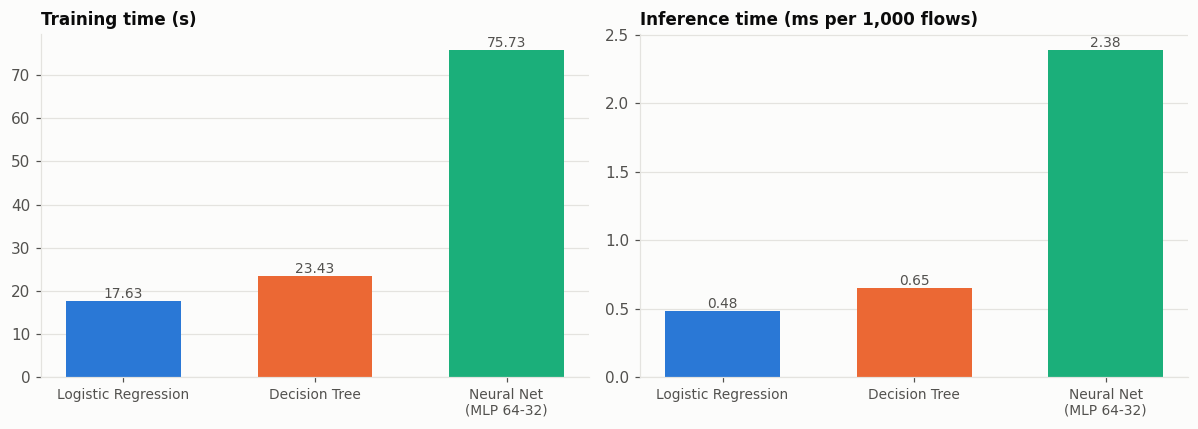

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
r = results_table()
for a, col, ttl in [(ax[0], "Train time (s)", "Training time (s)"),
                    (ax[1], "Predict ms / 1k flows", "Inference time (ms per 1,000 flows)")]:
    bars = a.bar(range(len(ALL)), r.loc[ALL, col], color=[MODEL_CLR[n] for n in ALL], width=0.6)
    a.set_xticks(range(len(ALL))); a.set_xticklabels([n.replace(" (", "\n(") for n in ALL], fontsize=9)
    a.bar_label(bars, fmt="%.2f", color=INK2, fontsize=9); a.set_title(ttl); a.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

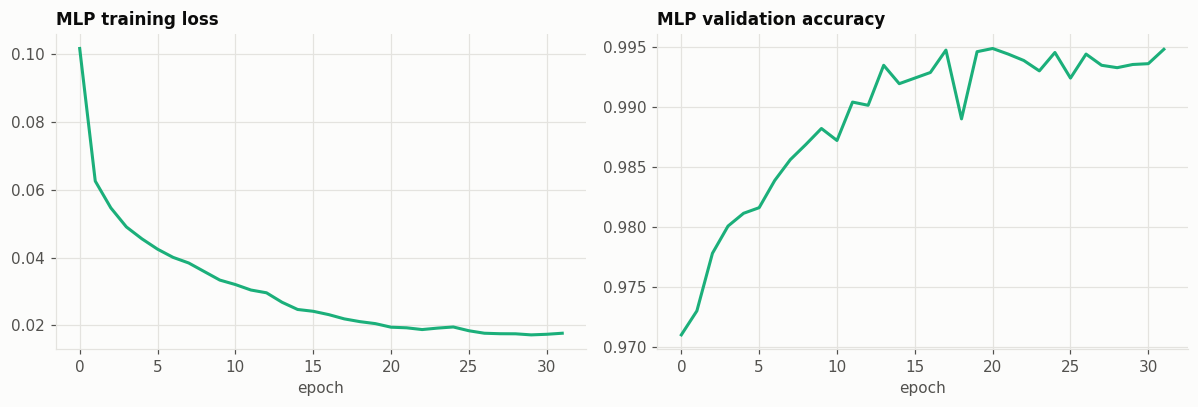

Stopped after 32 epochs


In [47]:
# Neural network learning curve
mlp = fitted["Neural Net (MLP 64-32)"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(mlp.loss_curve_, color=MODEL_CLR["Neural Net (MLP 64-32)"]); ax[0].set_title("MLP training loss")
ax[1].plot(mlp.validation_scores_, color=MODEL_CLR["Neural Net (MLP 64-32)"]); ax[1].set_title("MLP validation accuracy")
for a in ax: a.set_xlabel("epoch")
plt.tight_layout(); plt.show()
print("Stopped after", mlp.n_iter_, "epochs")

In [48]:
# Auto-generated summary of the comparison
r = results_table()
mlp_n, lr_n, dt_n = "Neural Net (MLP 64-32)", "Logistic Regression", "Decision Tree"
best = r["F1-score"].idxmax()
print(f"Best F1: {best} ({r.loc[best, 'F1-score']:.4f})")
print(f"F1 difference, MLP minus best classical: {r.loc[mlp_n, 'F1-score'] - r.loc[[lr_n, dt_n], 'F1-score'].max():+.4f}")
print(f"MLP training time vs Decision Tree: {r.loc[mlp_n, 'Train time (s)'] / r.loc[dt_n, 'Train time (s)']:.1f}x")
print(f"MLP training time vs Logistic Regression: {r.loc[mlp_n, 'Train time (s)'] / r.loc[lr_n, 'Train time (s)']:.1f}x")
print(f"Parameters in MLP: {sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_):,}")

Best F1: Decision Tree (0.9889)
F1 difference, MLP minus best classical: -0.0056
MLP training time vs Decision Tree: 3.2x
MLP training time vs Logistic Regression: 4.3x
Parameters in MLP: 6,849


Test accuracy by model
--------------------------------------
Decision Tree            0.9962  (99.62%)
Neural Net (MLP 64-32)   0.9944  (99.44%)
Logistic Regression      0.9351  (93.51%)


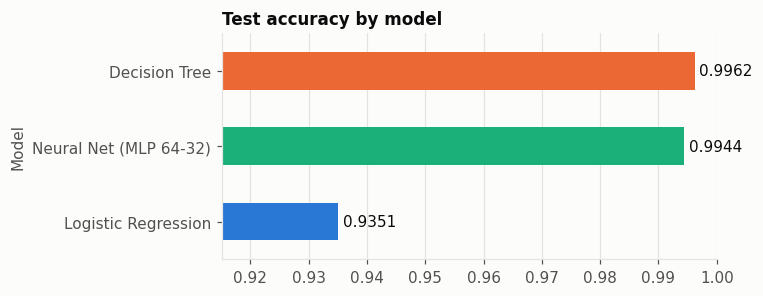

In [49]:
acc = results_table()["Accuracy"].sort_values(ascending=False)
print("Test accuracy by model\n" + "-" * 38)
for name, a in acc.items():
    print(f"{name:<24} {a:.4f}  ({a:.2%})")

ax = acc.sort_values().plot.barh(figsize=(7, 2.8), color=[MODEL_CLR[n] for n in acc.sort_values().index])
ax.set_xlim(max(0, acc.min() - 0.02), 1.0); ax.set_title("Test accuracy by model"); ax.grid(axis="y", visible=False)
ax.bar_label(ax.containers[0], fmt="%.4f", padding=3); plt.tight_layout(); plt.show()